In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("creditc_def.csv")

In [3]:
df.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default
0,1,20000,F,University,Married,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,Y
1,2,120000,F,University,Single,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,Y
2,3,90000,F,University,Single,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,N
3,4,50000,F,University,Married,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,N
4,5,50000,M,University,Married,57,-1,0,-1,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,N


In [4]:
df['default '].unique()

<ArrowStringArray>
['Y', 'N']
Length: 2, dtype: str

In [5]:
df.columns

Index(['ID', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0',
       'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2',
       'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1',
       'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'default '],
      dtype='str')

In [6]:
df.rename(columns={"default ": "default"}, inplace=True)

In [7]:
df.columns

Index(['ID', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0',
       'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2',
       'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1',
       'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'default'],
      dtype='str')

In [8]:
df['default'] = df['default'].map({'Y': 1, 'N': 0})

In [9]:
df['default'].unique()

array([1, 0])

In [10]:
df.isnull().sum()

ID           0
LIMIT_BAL    0
SEX          0
EDUCATION    0
MARRIAGE     0
AGE          0
PAY_0        0
PAY_2        0
PAY_3        0
PAY_4        0
PAY_5        0
PAY_6        0
BILL_AMT1    0
BILL_AMT2    0
BILL_AMT3    0
BILL_AMT4    0
BILL_AMT5    0
BILL_AMT6    0
PAY_AMT1     0
PAY_AMT2     0
PAY_AMT3     0
PAY_AMT4     0
PAY_AMT5     0
PAY_AMT6     0
default      0
dtype: int64

In [11]:
df['default'].value_counts()

default
0    23364
1     6636
Name: count, dtype: int64

<Axes: xlabel='default'>

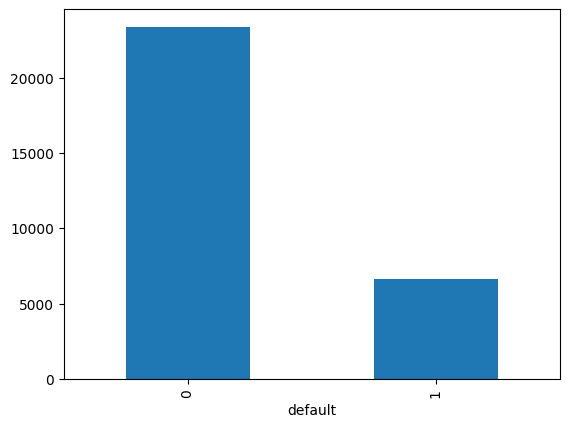

In [12]:
df['default'].value_counts().plot(kind='bar')

In [13]:
df1 = df.drop('ID', axis=1)
df1.columns

Index(['LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2',
       'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2',
       'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1',
       'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'default'],
      dtype='str')

In [14]:
X = df1.drop('default', axis=1)
y = df1['default']

In [15]:
X.shape

(30000, 23)

In [16]:
y.shape

(30000,)

In [17]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [18]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(24000, 23)
(6000, 23)
(24000,)
(6000,)


In [19]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=1000,  class_weight ='balanced')
model.fit(X_train, y_train)
# My error in this cell was that I was trying to run LogisticRegression on a training set that had string value columns.

ValueError: could not convert string to float: 'F'

In [20]:
X_train.dtypes

LIMIT_BAL    int64
SEX            str
EDUCATION      str
MARRIAGE       str
AGE          int64
PAY_0        int64
PAY_2        int64
PAY_3        int64
PAY_4        int64
PAY_5        int64
PAY_6        int64
BILL_AMT1    int64
BILL_AMT2    int64
BILL_AMT3    int64
BILL_AMT4    int64
BILL_AMT5    int64
BILL_AMT6    int64
PAY_AMT1     int64
PAY_AMT2     int64
PAY_AMT3     int64
PAY_AMT4     int64
PAY_AMT5     int64
PAY_AMT6     int64
dtype: object

In [21]:
X_train['SEX'].unique()

<ArrowStringArray>
['F', 'M']
Length: 2, dtype: str

In [22]:
X_train['EDUCATION'].unique()

<ArrowStringArray>
['University', 'Unknown', 'Graduate school', 'High School', 'Others', '0']
Length: 6, dtype: str

In [23]:
X_train['MARRIAGE'].unique()

<ArrowStringArray>
['Single', 'Married', 'Other', '0']
Length: 4, dtype: str

In [24]:
X_train['SEX'] = X_train['SEX'].map({'M': 0, 'F': 1})
X_test['SEX'] = X_test['SEX'].map({'M': 0, 'F': 1})
X_train = pd.get_dummies(X_train, columns=['EDUCATION', 'MARRIAGE'], dtype=int)
X_test = pd.get_dummies(X_test, columns=['EDUCATION', 'MARRIAGE'], dtype=int)

In [25]:
X_train.shape
feature_names = X_train.columns

In [26]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=1000,  class_weight ='balanced')
model.fit(X_train, y_train)
# My error here was that the data was not scaled before fitting the model 
# making it difficult for the lbfgs solver to converge within the iteration limit. 

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:470: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [27]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [28]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=2000,  class_weight ='balanced')
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'lbfgs'
,max_iter,2000
,multi_class,'deprecated'


In [29]:
from sklearn.metrics import classification_report

predictions = model.predict(X_test)

print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       0.88      0.70      0.78      4687
           1       0.38      0.65      0.48      1313

    accuracy                           0.69      6000
   macro avg       0.63      0.68      0.63      6000
weighted avg       0.77      0.69      0.71      6000



In [30]:
from sklearn.metrics import roc_auc_score

probabilities = model.predict_proba(X_test)[:, 1]

auc_score = roc_auc_score(y_test, probabilities)

print(auc_score)

0.7290278518259008


In [31]:
from sklearn.ensemble import RandomForestClassifier

clf = RandomForestClassifier(n_estimators=100, class_weight = 'balanced', random_state=42)
clf.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [32]:
rf_predictions = clf.predict(X_test)
print(classification_report(y_test, rf_predictions))

rf_probs = clf.predict_proba(X_test)[:, 1]
rf_auc = roc_auc_score(y_test, rf_probs)
print(rf_auc)

              precision    recall  f1-score   support

           0       0.84      0.95      0.89      4687
           1       0.66      0.34      0.45      1313

    accuracy                           0.82      6000
   macro avg       0.75      0.65      0.67      6000
weighted avg       0.80      0.82      0.79      6000

0.765467544768624


<Axes: >

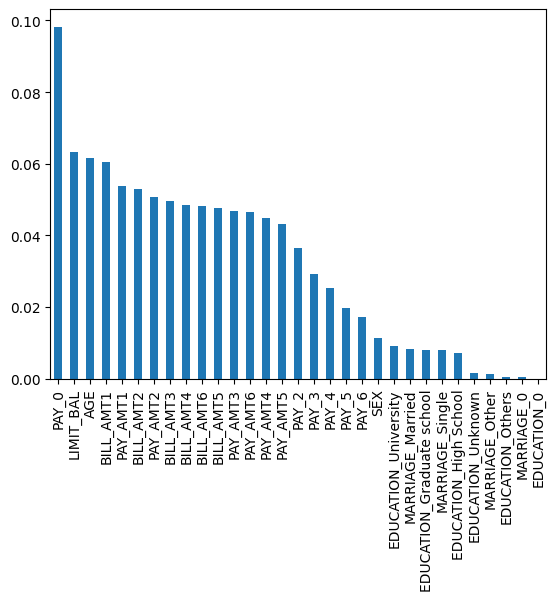

In [35]:
importances = pd.Series(clf.feature_importances_, index=feature_names)
importances.sort_values(ascending=False).plot(kind='bar')

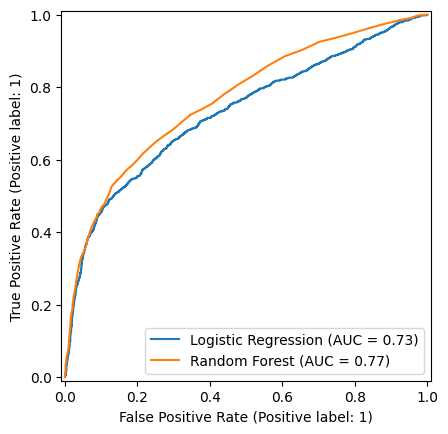

In [37]:
from sklearn.metrics import RocCurveDisplay
import matplotlib.pyplot as plt

log_reg_probs = model.predict_proba(X_test)[:, 1]
random_forest_probs = clf.predict_proba(X_test)[:, 1]

roc_display = RocCurveDisplay.from_predictions(
    y_test,
    log_reg_probs,
    name="Logistic Regression"
)

RocCurveDisplay.from_predictions(
    y_test,
    random_forest_probs,
    name="Random Forest",
    ax=roc_display.ax_
)

plt.show()

In [38]:
rf_predictions = clf.predict(X_test)

comparison = pd.DataFrame({
    "Actual": y_test,
    "Predicted": rf_predictions
})

wrong_predictions = comparison[comparison["Actual"] != comparison["Predicted"]]

false_negatives = wrong_predictions[
    (wrong_predictions["Actual"] == 1) & 
    (wrong_predictions["Predicted"] == 0)
]

false_positives = wrong_predictions[
    (wrong_predictions["Actual"] == 0) & 
    (wrong_predictions["Predicted"] == 1)
]

print(wrong_predictions.head())

print(false_negatives.head())

       Actual  Predicted
2664        1          0
5148        1          0
10784       0          1
3931        1          0
21457       1          0
       Actual  Predicted
2664        1          0
5148        1          0
3931        1          0
21457       1          0
22567       1          0


In [39]:
false_negative_indices = false_negatives.index

false_negative_customers = df.loc[false_negative_indices]

columns_to_check = [
    "PAY_0",
    "BILL_AMT1",
    "BILL_AMT2",
    "PAY_AMT1",
    "PAY_AMT2"
]

print(false_negative_customers[columns_to_check].head())

       PAY_0  BILL_AMT1  BILL_AMT2  PAY_AMT1  PAY_AMT2
2664       0      94228      47635      2000      1500
5148       1       7128       1852         0      1000
3931       0     105356     107588      3931      9600
21457      0       8031       9269      2009      2626
22567     -2          0          0         0         0
